# Conditional Volatility Models

Notebook 08 modeled temporal dependence in conditional means. A fitted mean model can leave residuals whose signs show little serial correlation but whose magnitudes cluster. ARCH and GARCH model this dependence through conditional variance.

I define the models and their moment conditions, then estimate, identify variance dependence, check residuals and compare a small candidate set. Forecasting concerns future conditional variance, which differs from unconditional variance and one realized squared return. Notebook 10 combines conditional means and variances in one model.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from finstats.diagnostics import acf, ljung_box

from arch import arch_model
from finstats.diagnostics import mcleod_li, standardized_residuals
from finstats.simulation import simulate_arch1, simulate_garch11
from finstats.volatility import garch11_forecast

def stem_dependence(ax, values, title, nobs, ylabel="Correlation"):
    lags = np.arange(len(values))
    ax.vlines(lags, 0, values, color="C0", linewidth=1.2)
    ax.scatter(lags, values, s=10, color="C0")
    ax.axhline(0, color="0.6", linewidth=.8)
    # Pointwise reference limits under an IID white-noise null, excluding lag zero.
    bound = stats.norm.ppf(.975)/np.sqrt(nobs)
    ax.hlines([bound,-bound], .5, lags[-1]+.5, color="0.35", linestyle="--",
              linewidth=.9, label="Approx. 95% white-noise bounds")
    ax.set(xlabel="Lag", ylabel=ylabel, title=title)

def dependence_panel(ax, values, title, nobs):
    stem_dependence(ax, values, title, nobs, ylabel="Sample correlation")

from finstats.risk import gaussian_var, gaussian_es


## 1. ARCH Models: ARCH(q)

Volatility clustering concerns the magnitude of movements. For a mean-zero innovation $a_t$, distinguish unconditional variance from variance given the observed past:
$$\operatorname{Var}(a_t)\qquad\text{and}\qquad\operatorname{Var}(a_t\mid\mathcal F_{t-1})=\sigma_t^2.$$
If $E[a_t\mid\mathcal F_{t-1}]=0$, the law of total variance gives $\operatorname{Var}(a_t)=E[\sigma_t^2]$. Stable unconditional variance therefore permits changing conditional variance.

### ARCH(1)

Begin with a conditional variance driven by one previous squared innovation.

#### Model

**Definition: ARCH(1).** The current innovation has a scale determined by the preceding squared innovation:
$$a_t=\sigma_t\nu_t,\qquad\sigma_t^2=\omega+\alpha a_{t-1}^2.$$
The standardized innovations $\nu_t$ are IID, independent of past information, with mean zero and variance one. Initially, $\nu_t\sim N(0,1)$. Here $\sigma_t$ is conditional standard deviation, and $\sigma_t^2$ is conditional variance.

#### Population Moments

Independence of $\nu_t$ from the past gives
$$E[a_t\mid\mathcal F_{t-1}]=0,\qquad E[a_t]=0,\qquad
\operatorname{Var}(a_t\mid\mathcal F_{t-1})=\sigma_t^2.$$
In the finite-variance stationary case,
$$v=\omega+\alpha v\quad\Longrightarrow\quad\operatorname{Var}(a_t)=\frac\omega{1-\alpha}.$$
For $s<t$, $E[a_sa_t]=E[a_sE(a_t\mid\mathcal F_{t-1})]=0$. Observations are serially uncorrelated, but their magnitudes can be dependent. With $\eta_t=a_t^2-\sigma_t^2$,
$$a_t^2=\omega+\alpha a_{t-1}^2+\eta_t.$$
This AR(1)-type recursion gives $\operatorname{Corr}(a_t^2,a_{t-j}^2)=\alpha^j$ only when fourth moments exist.

#### Positivity and Stationarity Conditions

Require $\omega>0$ and $\alpha\ge0$. The finite-second-moment stationary solution requires $\alpha<1$. With Gaussian innovations, a finite fourth moment additionally requires $3\alpha^2<1$. These are different moment conditions. The course example $\alpha=.8$ has finite return variance but no finite fourth moment, so its squared sample ACF is descriptive rather than an estimate of a defined population squared correlation.

### ARCH(q)

Several squared-innovation lags extend the same conditional-variance mechanism.

#### Model

**Definition: ARCH(q).** The conditional variance depends on q preceding squared innovations:
$$a_t=\sigma_t\nu_t,\qquad\sigma_t^2=\omega+\sum_{j=1}^q\alpha_j a_{t-j}^2.$$

#### Population Moments

The conditional and unconditional means remain zero, and $\operatorname{Var}(a_t\mid\mathcal F_{t-1})=\sigma_t^2$. In the finite-variance stationary case,
$$\operatorname{Var}(a_t)=\frac\omega{1-\sum_j\alpha_j}.$$
Squares have an AR(q)-type recursion. A covariance-stationary interpretation of squares additionally requires finite fourth moments.

#### Positivity and Stationarity Conditions

Require $\omega>0$, $\alpha_j\ge0$ and $\sum_j\alpha_j<1$ for the finite-second-moment stationary solution. Many squared-innovation lags can be cumbersome, motivating GARCH's parsimonious variance feedback.

### Illustration: Volatility Persistence

For illustration, I retain the course's Gaussian ARCH(1) specification, $\omega=2$, $\alpha=.8$, n=600 and seed 123. I compare $\alpha=.2$ with $\omega=8$, keeping unconditional variance ten in both cases. Shared standardized innovations isolate the effect of changing persistence. All history illustrations display observations 1–600. The question is how conditional standard deviation responds to recent large observations when persistence differs. The horizontal reference is the constant unconditional SD, $\sqrt{10}$, not the mean of conditional SD.

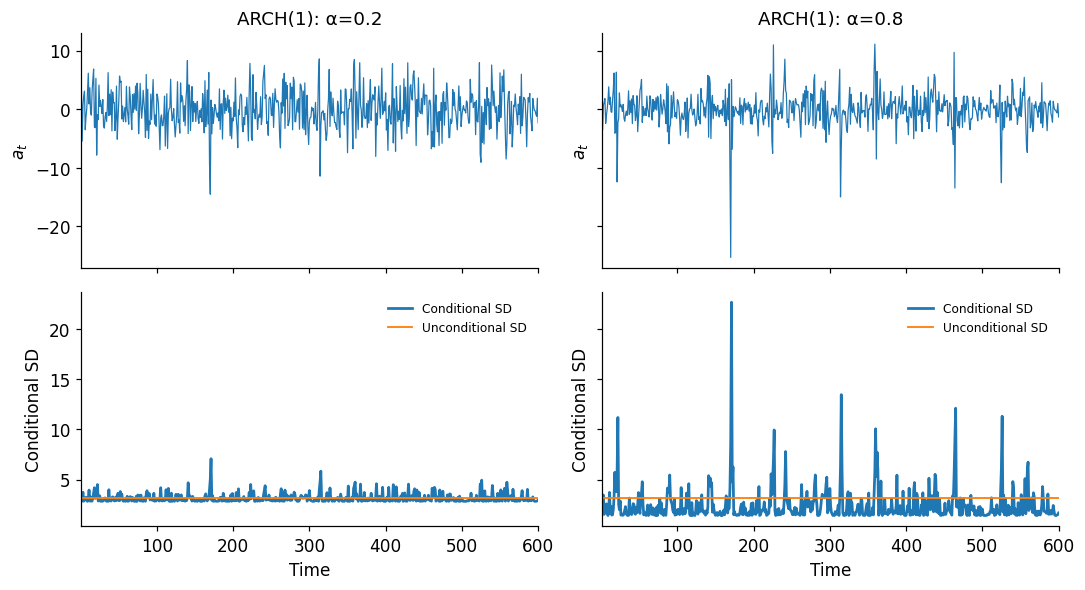

In [2]:
arch_returns, arch_variances = simulate_arch1(2,.8,600,rng=123)
fig, axes = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True, sharey="row")
for column, alpha in enumerate([.2,.8]):
    values, variances = simulate_arch1(10*(1-alpha), alpha, 600, rng=123)
    times = np.arange(1,601)
    axes[0,column].plot(times, values[:600], linewidth=.8)
    axes[0,column].set(title=f"ARCH(1): α={alpha:g}", ylabel="$a_t$")
    axes[1,column].plot(times, np.sqrt(variances[:600]), label="Conditional SD")
    axes[1,column].axhline(np.sqrt(10), color="C1", linewidth=1.2,
                          label="Unconditional SD")
    axes[1,column].legend(fontsize=8)
    axes[1,column].set(xlabel="Time", ylabel="Conditional SD", xlim=(1,600))
fig.tight_layout(); plt.show()

Greater ARCH persistence makes variance more responsive to the recent history. Both specifications have the same unconditional variance, but their finite realizations differ.

## 2. GARCH Models: GARCH(p,q)

GARCH adds lagged conditional variance to the ARCH equation. GARCH(1,1) is a parsimonious starting point for persistent volatility, rather than a guarantee that every form of variance dependence is captured.

### GARCH(1,1)

Adding lagged conditional variance captures persistent volatility with few parameters.

#### Model

**Definition: GARCH(1,1).** One squared-innovation lag and one variance lag determine the current conditional variance:
$$a_t=\sigma_t\nu_t,\qquad\sigma_t^2=\omega+\alpha a_{t-1}^2+\beta\sigma_{t-1}^2.$$
The standardized innovations have the same assumptions as above. The intercept $\omega$ is a variance input, $\alpha$ controls the response to a recent squared innovation, and $\beta$ carries conditional variance forward.

#### Population Moments

Conditional and unconditional means are zero, and conditional variance is $\sigma_t^2$. For a finite-variance stationary solution,
$$v=\omega+(\alpha+\beta)v\quad\Longrightarrow\quad
\operatorname{Var}(a_t)=\sigma_\infty^2=\frac\omega{1-\alpha-\beta}.$$
Persistence $\alpha+\beta$ near one means slow reversion of expected variance. Defining $\eta_t=a_t^2-\sigma_t^2$ gives
$$a_t^2=\omega+(\alpha+\beta)a_{t-1}^2-\beta\eta_{t-1}+\eta_t.$$
This is an ARMA(1,1)-type recursion in squares, linking to Notebook 08. Its covariance-stationary interpretation requires finite fourth moments.

#### Positivity and Stationarity Conditions

Require $\omega>0$, $\alpha,\beta\ge0$ and $\alpha+\beta<1$ for finite-second-moment stationarity. With Gaussian innovations, a finite fourth moment additionally requires $3\alpha^2+2\alpha\beta+\beta^2<1$. The second-moment condition alone does not guarantee all higher moments.

### GARCH(p,q)

Additional variance and squared-innovation lags generalize the one-lag specification.

#### Model

**Definition: GARCH(p,q).** Under the course convention, q counts squared-innovation lags and p counts variance lags:
$$\sigma_t^2=\omega+\sum_{i=1}^q\alpha_i a_{t-i}^2+\sum_{j=1}^p\beta_j\sigma_{t-j}^2.$$
The Python `arch` package reverses these order names: its `p` counts squared-innovation lags and its `q` counts variance lags. For (1,1), the conventions coincide.

#### Population Moments

The means remain zero and conditional variance is $\sigma_t^2$. In the finite-variance stationary case,
$$\operatorname{Var}(a_t)=\frac\omega{1-\sum_i\alpha_i-\sum_j\beta_j}.$$
The squared process has an ARMA-type recursion, with the same fourth-moment qualification as above.

#### Positivity and Stationarity Conditions

Require a positive intercept, nonnegative coefficients and $\sum_i\alpha_i+\sum_j\beta_j<1$ for a finite-second-moment stationary solution.

### Illustration: Variance Feedback

For illustration, I compare $\alpha=.05$, $\beta=.5$ and $.9$, choosing $\omega=1-\alpha-\beta$ so both population variances equal one. I use 1500 observations, seed 612 and the same standardized innovations. The higher-persistence specification is also used for estimation below. The figure asks how adding persistent variance feedback changes the realized conditional variance. The horizontal line marks the common unconditional variance of one in both specifications.

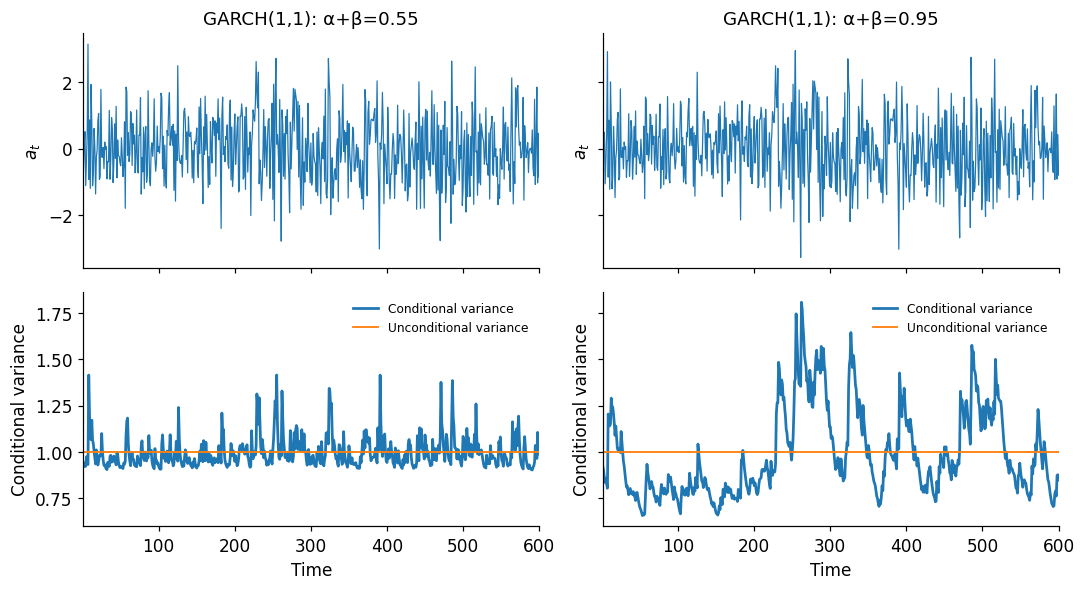

In [3]:
simulated_returns, simulated_variances = simulate_garch11(.05,.05,.9,1500,rng=612)
fig, axes = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True, sharey="row")
for column, beta in enumerate([.5,.9]):
    values, variances = simulate_garch11(1-.05-beta,.05,beta,1500,rng=612)
    times = np.arange(1,601)
    axes[0,column].plot(times, values[:600], linewidth=.8)
    axes[0,column].set(title=f"GARCH(1,1): α+β={.05+beta:g}", ylabel="$a_t$")
    axes[1,column].plot(times, variances[:600], label="Conditional variance")
    axes[1,column].axhline(1., color="C1", linewidth=1.2, label="Unconditional variance")
    axes[1,column].legend(fontsize=8)
    axes[1,column].set(xlabel="Time", ylabel="Conditional variance", xlim=(1,600))
fig.tight_layout(); plt.show()
# Reserve the final 300 observations before fitting; forecasts evaluate the first 24.
returns = pd.Series(simulated_returns[:1200], name="Innovation")
forecast_horizon = 24

Higher persistence slows variance reversion. The realized history alone does not determine the appropriate GARCH orders.

## 3. Estimation, Diagnostics and Evaluation

Estimate the model, check remaining dependence and assess whether its distributional assumptions and complexity are supported.

### Maximum Likelihood Estimation

Notebook 03 introduced likelihood as a function of unknown parameters for the observed sample. For time-series data, conditional densities account for the observed past:
$$\ell_c(\theta)=\sum_t\log f_\theta(x_t\mid\mathcal F_{t-1}),\qquad
\hat\theta=\underset{\theta\in\Theta}{\arg\max}\;\ell_c(\theta).$$
The sum runs over estimation observations after the chosen initialization. Log-likelihood turns a product of conditional densities into a sum without changing its maximizer.

ARCH/GARCH specify a changing conditional variance. Their standardized innovations are IID with mean zero and variance one, independently of the past. Under finite-variance stationarity, the unstandardized innovations are white noise but generally dependent: their squared magnitudes carry information about future variance. White noise alone does not specify the density needed for likelihood.

The worked fits use Gaussian or standardized Student-t innovation densities. The Student-t requires degrees of freedom above two and is scaled to unit variance, preserving the interpretation of the fitted scale as conditional standard deviation. Changing variance can create unconditional heavy tails even with Gaussian standardized innovations.

#### Numerical Solutions and Starting Values

ARCH/GARCH MLEs generally have no closed-form solution. I use `arch` for constrained numerical optimization. Convergence can depend on starting parameter values and may reach a local rather than global optimum. Rerunning from several admissible starting vectors and comparing converged log-likelihoods is a useful check, but does not guarantee the global optimum. This changes optimizer starting values, not the observed dataset. The example uses the package's default initialization and checks convergence.

#### Example: Estimating GARCH(1,1)

I fit the first 1200 observations of the simulated Gaussian GARCH(1,1) path, reserving the remaining 300 out of sample. One compact table reports estimates and approximate standard errors. The Gaussian model remains the benchmark for diagnostics and forecasting; a Student-t fit illustrates the alternative density assumption. Notebook 10 adds a conditional-mean equation.

In [4]:
gaussian_garch = arch_model(returns, mean="Zero", vol="GARCH", p=1, q=1,
                            dist="normal", rescale=False).fit(disp="off", update_freq=0)
student_garch = arch_model(returns, mean="Zero", vol="GARCH", p=1, q=1,
                           dist="t", rescale=False).fit(disp="off", update_freq=0)
for fit in (gaussian_garch, student_garch):
    assert fit.convergence_flag == 0
display(pd.DataFrame({"Estimate":gaussian_garch.params,
                      "Standard error":gaussian_garch.std_err}).round(4))

,Estimate,Standard error
omega,0.0491,0.0211
alpha[1],0.0502,0.0160
beta[1],0.8987,0.0316


### Model Identification

Identification first asks whether conditional-variance dependence remains after accounting for the mean. Here the simulated population mean is zero, so observations themselves are innovations. For real data, examine residuals from an appropriate mean model.

#### Squared-Residual ACF and ARCH Effects

The level ACF can be weak while the squared-residual ACF shows magnitude dependence. This motivates checking conditional heteroskedasticity, rather than reading an exact GARCH order from the plots.

#### McLeod–Li Test

The McLeod–Li test applies the Ljung–Box statistic to squared residuals. With $\hat\rho_{2,j}$ denoting their sample autocorrelation at lag j, the null and statistic are
$$H_0:\rho_{2,1}=\cdots=\rho_{2,h}=0,$$
$$Q_{McL}=T(T+2)\sum_{j=1}^{h}\frac{\hat\rho_{2,j}^{\,2}}{T-j}.$$
Under the null, the conventional approximate reference is $\chi_h^2$, using denominator-T sample autocovariances. A small p-value supports remaining magnitude dependence, not a particular ARCH/GARCH order. The screen needs finite fourth moments and is not an exact post-estimation test.

#### Choosing Candidate Orders

Plots do not reliably distinguish exact GARCH orders. GARCH(1,1) offers a parsimonious starting point; additional ARCH or variance lags are assessed through likelihood criteria and residual diagnostics.

#### Example: Detecting Variance Dependence

The Gaussian GARCH simulation has finite fourth moments. I compare its estimation-sample level and squared ACF, then apply the squared-series screen. The question is whether weak level correlation hides dependence in magnitude.

Dashed lines show the approximate pointwise 95% white-noise reference bounds $\pm1.96/\sqrt{n}$, using the number of observations in each plotted sample. They are centered on zero, not on the estimated correlations or population curve. Exceeding a bound flags possible dependence; these are not simultaneous bounds, and fitted-residual and squared-series interpretations remain approximate and require suitable moment assumptions.

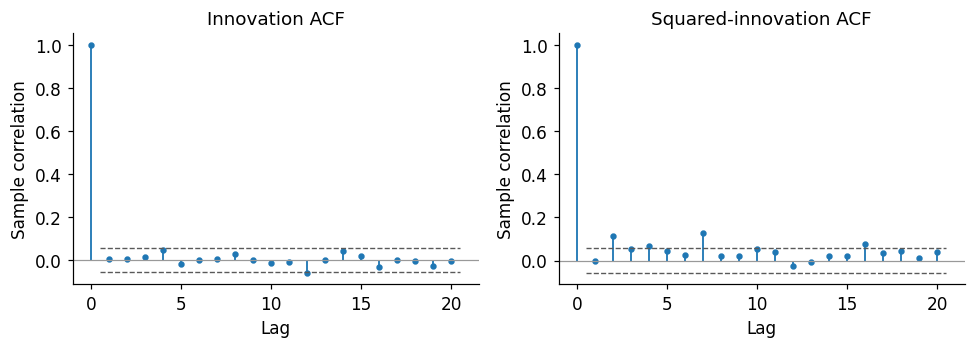

,statistic,p_value,df,lags,nobs
0,70.7947,0.0,20,20,1200


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
dependence_panel(axes[0], acf(returns,20,adjusted=False), "Innovation ACF", len(returns))
dependence_panel(axes[1], acf(np.asarray(returns)**2,20,adjusted=False), "Squared-innovation ACF", len(returns))
fig.tight_layout(); plt.show()
display(pd.DataFrame([mcleod_li(np.asarray(returns),20)]).round(4))

The squared-series check evaluates magnitude dependence that the level ACF can miss. It motivates a conditional-variance model without determining its order.

### Residual Diagnostics

After fitting the variance model, I ask whether it removes the magnitude dependence that motivated it. Innovations and conditional variances are population quantities; fitted residuals and variances are estimates.

#### Standardized Residuals and Tests

**Definition: standardized residual.** Divide the fitted innovation by its fitted conditional standard deviation:
$$\hat\nu_t=\hat a_t/\hat\sigma_t.$$
Ljung–Box checks linear correlation in standardized residuals. The McLeod–Li screen defined above checks their squares for remaining magnitude dependence. With Student-t degrees of freedom at most four, squared standardized innovations lack finite variance, so I omit the nominal squared-screen p-value.

#### ACF of Standardized Residuals and Their Squares

Both ACFs should show little remaining dependence for an adequate model. This is diagnostic evidence, rather than proof of independence or the innovation density.

#### Example: Checking the Fitted GARCH Models

I show both ACFs for the Gaussian benchmark and report checks for the Gaussian and Student-t fits on the same estimation observations.

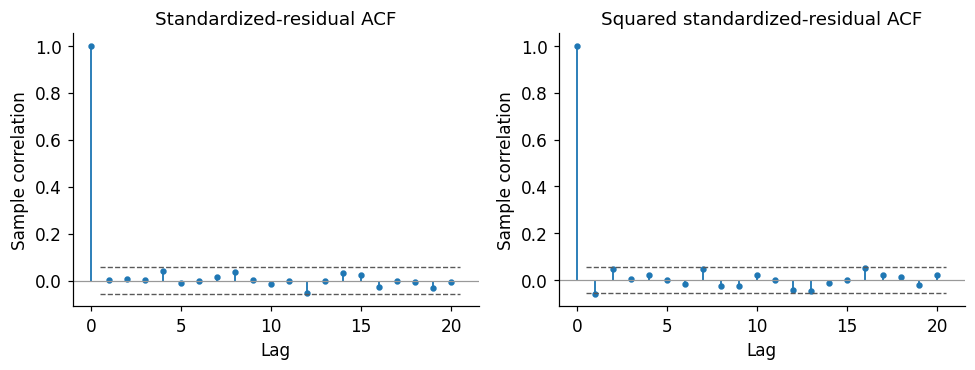

,Innovations,Series,statistic,p_value,df,lags,nobs
0,Gaussian,Standardized,12.110353,0.912225,20,20,1200
1,Gaussian,Squared standardized,21.810555,0.350878,20,20,1200
2,Student-t,Standardized,12.111987,0.912168,20,20,1200
3,Student-t,Squared standardized,21.820845,0.350311,20,20,1200


In [6]:
gaussian_standardized = standardized_residuals(np.asarray(gaussian_garch.resid), np.asarray(gaussian_garch.conditional_volatility))
student_standardized = standardized_residuals(np.asarray(student_garch.resid), np.asarray(student_garch.conditional_volatility))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
dependence_panel(axes[0], acf(gaussian_standardized, 20, adjusted=False), "Standardized-residual ACF", len(gaussian_standardized))
dependence_panel(axes[1], acf(gaussian_standardized**2, 20, adjusted=False), "Squared standardized-residual ACF", len(gaussian_standardized))
fig.tight_layout()
plt.show()
checks = []
for label, values, fit in (("Gaussian", gaussian_standardized, gaussian_garch), ("Student-t", student_standardized, student_garch)):
    squared_check = mcleod_li(values, 20)
    if fit.params.get("nu", np.inf) <= 4:
        squared_check["p_value"] = np.nan
    checks.extend([{"Innovations":label, "Series":"Standardized", **ljung_box(values, 20)}, {"Innovations":label, "Series":"Squared standardized", **squared_check}])
display(pd.DataFrame(checks))

### Model Selection: AIC and BIC

As in Notebooks 03 and 08,
$$AIC=-2\ell(\hat\theta)+2m,\qquad BIC=-2\ell(\hat\theta)+m\log n.$$
The parameter count includes innovation-distribution parameters when estimated. Compare the same observations, mean specification and likelihood initialization. Lower criteria favor a candidate, but do not guarantee adequate residuals or better forecasts.

#### Example: ARCH versus GARCH

I compare Gaussian ARCH(1), ARCH(2) and GARCH(1,1) on the same GARCH-generated estimation sample. The Student-t GARCH fit is included to assess the innovation-density alternative. The table asks whether likelihood gains justify additional parameters. The generating model need not win in every finite sample.

In [7]:
gaussian_arch = arch_model(returns,mean="Zero",vol="ARCH",p=1,dist="normal",rescale=False).fit(disp="off",update_freq=0)
gaussian_arch2 = arch_model(returns,mean="Zero",vol="ARCH",p=2,dist="normal",rescale=False).fit(disp="off",update_freq=0)
criteria_rows = []
for label, fit in [("Gaussian ARCH(1)",gaussian_arch),("Gaussian ARCH(2)",gaussian_arch2),
                   ("Gaussian GARCH(1,1)",gaussian_garch),("Student-t GARCH(1,1)",student_garch)]:
    assert fit.convergence_flag == 0
    m = len(fit.params)
    np.testing.assert_allclose(fit.aic,-2*fit.loglikelihood+2*m)
    np.testing.assert_allclose(fit.bic,-2*fit.loglikelihood+m*np.log(fit.nobs))
    criteria_rows.append({"Model":label,"Parameters":m,"Log-likelihood":fit.loglikelihood,
                         "AIC":fit.aic,"BIC":fit.bic})
display(pd.DataFrame(criteria_rows).set_index("Model").round(3))

,Parameters,Log-likelihood,AIC,BIC
Model,,,,
Gaussian ARCH(1),2,-1679.869,3363.738,3373.918
Gaussian ARCH(2),3,-1673.680,3353.360,3368.630
"Gaussian GARCH(1,1)",3,-1668.551,3343.101,3358.372
"Student-t GARCH(1,1)",4,-1668.737,3345.473,3365.833


## 4. Forecasting

Forecast conditional variance from past information, then translate conditional uncertainty into the quantities of interest.

### Definition

A variance forecast is the expectation of a future conditional variance given current information:
$$v_{n+h|n}=E[\sigma_{n+h}^2\mid\mathcal F_n].$$
For these mean-zero models it also equals $E[a_{n+h}^2\mid\mathcal F_n]$. It does not predict the exact squared observation. The following recursions substitute fitted parameters and omit parameter uncertainty.

### ARCH(q) Forecasts

For ARCH(1),
$$\hat v_{n+1|n}=\hat\omega+\hat\alpha a_n^2,\qquad
\hat v_{n+h|n}=\hat\omega+\hat\alpha\hat v_{n+h-1|n}\quad(h>1).$$
ARCH(q) applies the same substitution across q lags: retain observed squared innovations and replace future squares by their forecast expectations. The forecast approaches the fitted unconditional variance under the finite-variance stationarity condition.

### GARCH(p,q) Forecasts

For GARCH(1,1),
$$\hat v_{n+1|n}=\hat\omega+\hat\alpha a_n^2+\hat\beta\hat\sigma_n^2,$$
$$\hat v_{n+h|n}=\hat\omega+(\hat\alpha+\hat\beta)\hat v_{n+h-1|n}\quad(h>1).$$
With persistence below one,
$$\hat v_{n+h|n}=\hat\sigma_\infty^2+(\hat\alpha+\hat\beta)^{h-1}(\hat v_{n+1|n}-\hat\sigma_\infty^2).$$
General GARCH(p,q) uses the same expectation substitution for future squared innovations and future variances.

### Interpreting the Forecast

Conditional variance describes future uncertainty given the current history. It is not an observed squared return. The forecast standard deviation is the square root of forecast variance, rather than generally the expected future standard deviation. With fitted persistence below one, it approaches the implied long-run standard deviation.

These recursions follow from the model equations. Notebook 10 combines them with conditional-mean forecasts to show future-return uncertainty, following the course's combined-model presentation.

### Conditional Value at Risk and Expected Shortfall

Notebook 00 defined loss as the negative of return. Notebooks 01–04 developed loss quantiles and tail expectations, and Notebook 05 showed that a good in-sample distributional fit need not give accurate future risk estimates. Conditional volatility now lets the scale of the loss distribution respond to the observed history, rather than using a fixed unconditional threshold.

For this mean-zero example, define $L_t=-a_t$. At tail probability $\alpha=.05$, the earlier definitions apply conditionally:
$$VaR_{\alpha,t}=F_{L_t\mid\mathcal F_{t-1}}^{-1}(1-\alpha),\qquad
ES_{\alpha,t}=E[L_t\mid L_t>VaR_{\alpha,t},\mathcal F_{t-1}].$$
Under the fitted Gaussian innovation assumption, the conditional loss has mean zero and standard deviation $\hat\sigma_t$. I reuse the Gaussian loss functions from Notebook 01 with this changing scale. On a return plot, the corresponding lower-tail lines are $-VaR_{\alpha,t}$ and $-ES_{\alpha,t}$. A point below the VaR line is an exceedance; the ES line describes average loss beyond VaR, not another exceedance-frequency target.

### Example: In-Sample Conditional Volatility 

For illustration, I show 600 estimation observations with fitted ±2 conditional-SD bands. Dashed bands show ±2 of the known conditional SD from the simulated population. The question is whether the fitted model recovers the underlying time-varying uncertainty.

The conditional mean is zero. It does not track individual observations; the bands describe their changing scale. With Gaussian standardized innovations, the population one-step ±2 SD bands contain about 95.4% of outcomes conditionally. Fitted bands substitute estimated parameters and need not contain that fraction in this finite sample. This is an in-sample reconstruction, not evidence of out-of-sample forecast accuracy.

#### Time-Varying 5% Loss Risk

The two panels use the same 600 estimation observations. The first shows volatility bands; the second shows the implied 5% VaR and ES on the return scale. Larger conditional SD moves both risk lines downward. Their values depend on the innovation density as well as the volatility equation: a standardized Student-t fit would use its own quantiles and tail expectations.

The model parameters were estimated using the full estimation sample, so these curves are retrospective in-sample estimates, not rolling out-of-sample risk forecasts. They show how the model responds to changing uncertainty, without establishing that it solves the forecasting problems seen in Notebook 05. At the estimation cutoff, the one-step variance forecast also supplies a genuine next-period model-based VaR and ES, reported below in simulation units.

#### Visual Illustration

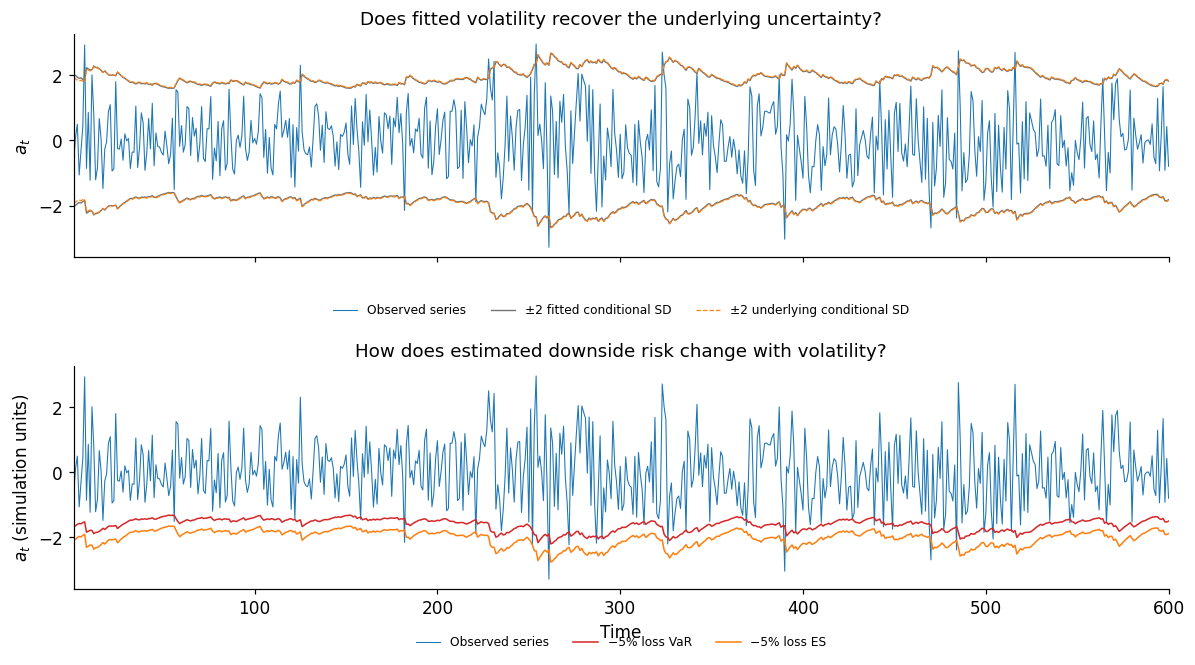

,One-step prediction
Conditional SD,0.9723
5% loss VaR,1.5993
5% loss ES,2.0056


In [8]:
params = gaussian_garch.params
last_residual = float(gaussian_garch.resid.iloc[-1])
last_variance = float(gaussian_garch.conditional_volatility.iloc[-1])**2
variance_forecast = garch11_forecast(last_residual,last_variance,params["omega"],
                                   params["alpha[1]"],params["beta[1]"],forecast_horizon)
package_forecast = gaussian_garch.forecast(horizon=forecast_horizon,reindex=False).residual_variance.iloc[-1].to_numpy()
np.testing.assert_allclose(variance_forecast,package_forecast,rtol=1e-10,atol=1e-10)
# Verify the ARCH(1) recursion against the package without a second forecast figure.
arch_forecast = gaussian_arch.forecast(horizon=forecast_horizon,reindex=False).variance.iloc[-1].to_numpy()
arch_explicit = np.empty(forecast_horizon)
arch_explicit[0] = gaussian_arch.params["omega"]+gaussian_arch.params["alpha[1]"]*float(gaussian_arch.resid.iloc[-1])**2
for j in range(1,forecast_horizon):
    arch_explicit[j] = gaussian_arch.params["omega"]+gaussian_arch.params["alpha[1]"]*arch_explicit[j-1]
np.testing.assert_allclose(arch_forecast,arch_explicit,rtol=1e-10)
times = np.arange(1,601)
observed = np.asarray(returns)[:600]
fitted_sd = np.asarray(gaussian_garch.conditional_volatility)[:600]
population_sd = np.sqrt(simulated_variances[:600])
alpha = .05
conditional_var = np.array([gaussian_var(0.,sd,alpha) for sd in fitted_sd])
conditional_es = np.array([gaussian_es(0.,sd,alpha) for sd in fitted_sd])
assert np.all(conditional_es >= conditional_var)
fig, axes = plt.subplots(2,1,figsize=(11,6.2),sharex=True)
axes[0].plot(times,observed,color="C0",linewidth=.7,label="Observed series")
axes[0].plot(times,2*fitted_sd,color="0.45",linewidth=.9,label="±2 fitted conditional SD")
axes[0].plot(times,-2*fitted_sd,color="0.45",linewidth=.9)
axes[0].plot(times,2*population_sd,color="C1",linestyle="--",linewidth=.8,
             label="±2 underlying conditional SD")
axes[0].plot(times,-2*population_sd,color="C1",linestyle="--",linewidth=.8)
axes[0].set(title="Does fitted volatility recover the underlying uncertainty?",ylabel="$a_t$")
axes[1].plot(times,observed,color="C0",linewidth=.7,label="Observed series")
axes[1].plot(times,-conditional_var,color="C3",linewidth=1,label="−5% loss VaR")
axes[1].plot(times,-conditional_es,color="C1",linewidth=1,label="−5% loss ES")
axes[1].set(title="How does estimated downside risk change with volatility?",
            xlabel="Time",ylabel="$a_t$ (simulation units)",xlim=(1,600))
for ax in axes:
    ax.legend(fontsize=8,ncol=3,loc="upper center",bbox_to_anchor=(.5,-.16))
fig.tight_layout();plt.show()
next_sd = np.sqrt(variance_forecast[0])
display(pd.DataFrame({"One-step prediction":[next_sd,gaussian_var(0.,next_sd,alpha),
                                            gaussian_es(0.,next_sd,alpha)]},
                     index=["Conditional SD","5% loss VaR","5% loss ES"]).round(4))


Conditional variance describes uncertainty given the observed past. Unconditional variance averages that uncertainty across possible histories, while one realized squared return is neither variance itself. Notebook 10 joins conditional-mean and conditional-variance equations before the later empirical application.